### Imports

In [1]:
import pycmap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Query

In [ ]:
api = pycmap.API(token='<YOUR TOKEN HERE>') # ADD API KEY HERE

# NES-LTER Flow Cytometry (Sosik)
df = api.get_dataset('tblSosik_flow_cytometry_NES_LTER')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Time range: {df['time'].min()} to {df['time'].max()}")
print(f"Unique time points: {df['time'].nunique()}")
print(f"Columns: {list(df.columns)}")

/opt/homebrew/Caskroom/miniforge/base/envs/tf-workshop/lib/python3.10/site-packages/pycmap/rest.py:334: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(df['JSON_stats'][0])
/opt/homebrew/Caskroom/miniforge/base/envs/tf-workshop/lib/python3.10/site-packages/pycmap/rest.py:335: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  rows = int(df.loc[['count'], 'lat'])


Shape: (61420, 26)
Time range: 2018-01-31 12:26:00 to 2022-02-21 13:35:00
Unique time points: 61417
Columns: ['time', 'lat', 'lon', 'depth', 'cruise', 'syn_cells_per_ml', 'redeuk_leq_2um_cells_per_ml', 'redeuk_leq_3um_cells_per_ml', 'redeuk_leq_5um_cells_per_ml', 'redeuk_leq_10um_cells_per_ml', 'redeuk_leq_20um_cells_per_ml', 'syn_biovolume_concentration', 'redeuk_leq_2um_biovolume_concentration', 'redeuk_leq_3um_biovolume_concentration', 'redeuk_leq_5um_biovolume_concentration', 'redeuk_leq_10um_biovolume_concentration', 'redeuk_leq_20um_biovolume_concentration', 'syn_carbon_concentration', 'redeuk_leq_2um_carbon_concentration', 'redeuk_leq_3um_carbon_concentration', 'redeuk_leq_5um_carbon_concentration', 'redeuk_leq_10um_carbon_concentration', 'redeuk_leq_20um_carbon_concentration', 'volume_analyzed_ml', 'filename', 'size_calibration_flag']


### Depth distribution and missingness

In [3]:
# Missing data
print("Missing data (%):")
print((df.isna().sum() / len(df) * 100).round(1).sort_values(ascending=False))

print(f"\nDepth range: {df['depth'].min()} to {df['depth'].max()}")
print(f"\nDepth distribution:")
print(df['depth'].describe())

Missing data (%):
time                                       0.0
lat                                        0.0
filename                                   0.0
volume_analyzed_ml                         0.0
redeuk_leq_20um_carbon_concentration       0.0
redeuk_leq_10um_carbon_concentration       0.0
redeuk_leq_5um_carbon_concentration        0.0
redeuk_leq_3um_carbon_concentration        0.0
redeuk_leq_2um_carbon_concentration        0.0
syn_carbon_concentration                   0.0
redeuk_leq_20um_biovolume_concentration    0.0
redeuk_leq_10um_biovolume_concentration    0.0
redeuk_leq_5um_biovolume_concentration     0.0
redeuk_leq_3um_biovolume_concentration     0.0
redeuk_leq_2um_biovolume_concentration     0.0
syn_biovolume_concentration                0.0
redeuk_leq_20um_cells_per_ml               0.0
redeuk_leq_10um_cells_per_ml               0.0
redeuk_leq_5um_cells_per_ml                0.0
redeuk_leq_3um_cells_per_ml                0.0
redeuk_leq_2um_cells_per_ml               

### Cruise summary

In [4]:
# Cruise locations and time coverage
cruise_summary = df.groupby('cruise').agg(
    n_samples=('time', 'size'),
    time_start=('time', 'min'),
    time_end=('time', 'max'),
    lat_min=('lat', 'min'),
    lat_max=('lat', 'max'),
    lon_min=('lon', 'min'),
    lon_max=('lon', 'max'),
).sort_values('time_start')

print(cruise_summary.to_string())

        n_samples          time_start            time_end   lat_min   lat_max  lon_min   lon_max
cruise                                                                                          
EN608        2551 2018-01-31 12:26:00 2018-02-05 12:58:00  39.74800  41.58690 -71.4121 -70.56590
AR28B        3799 2018-04-03 18:47:00 2018-04-13 12:22:00  39.77300  41.48200 -70.9440 -70.69500
AR29         5380 2018-04-16 23:05:00 2018-04-29 13:53:00  39.61200  41.39100 -71.0820 -70.24400
EN617        2673 2018-07-20 14:13:00 2018-07-25 09:06:00  39.71550  41.40330 -71.3637 -70.53860
AR31A        1333 2018-10-20 19:55:00 2018-10-23 12:32:00  40.35700  41.47000 -70.9270 -70.74100
EN627        2448 2019-02-01 17:00:00 2019-02-06 07:42:00  39.76330  41.46140 -71.4210 -70.44800
AR34B        3791 2019-04-14 15:59:00 2019-04-24 10:52:00  39.77200  41.47400 -70.9960 -70.67300
RB1904       6592 2019-05-12 14:39:00 2019-05-25 11:02:00  39.41000  41.43000 -71.3400 -70.60001
TN368        6569 2019-07-05 2

### Plot cruise locations

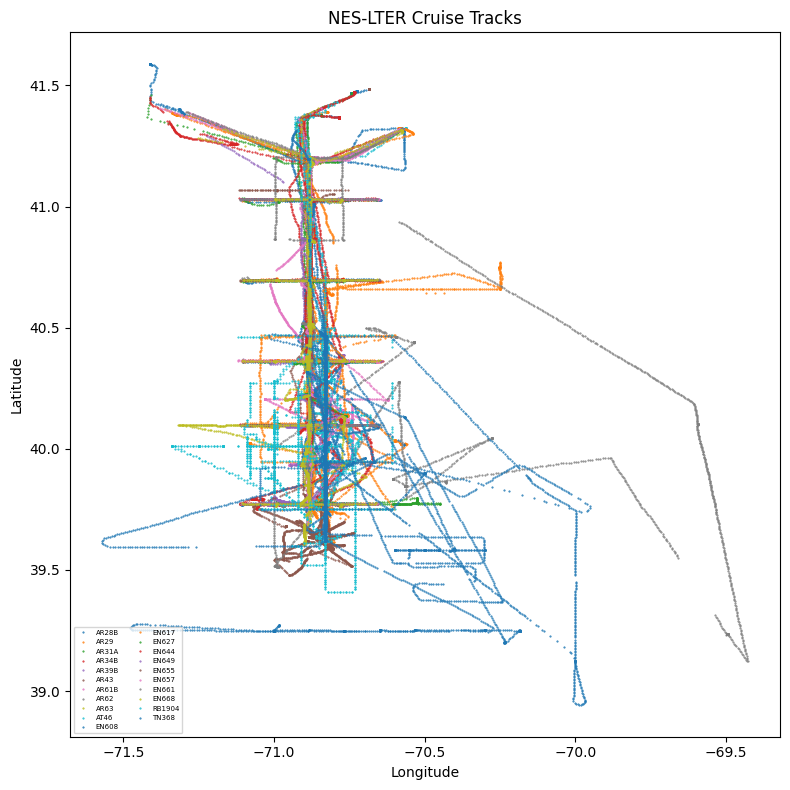

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
for cruise, grp in df.groupby('cruise'):
    ax.plot(grp['lon'], grp['lat'], '.', ms=1, label=cruise)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('NES-LTER Cruise Tracks')
ax.legend(fontsize=5, ncol=2, loc='lower left')
plt.tight_layout()
plt.savefig('nes_lter_cruise_tracks.png', dpi=150)
plt.show()

### Single cruise example

Cruise RB1904
  Samples: 6592
  Duration: 2019-05-12 14:39:00 to 2019-05-25 11:02:00
  Sampling interval (minutes):
count    6591.000000
mean        2.807313
std         3.623840
min         2.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        87.000000
Name: time, dtype: float64


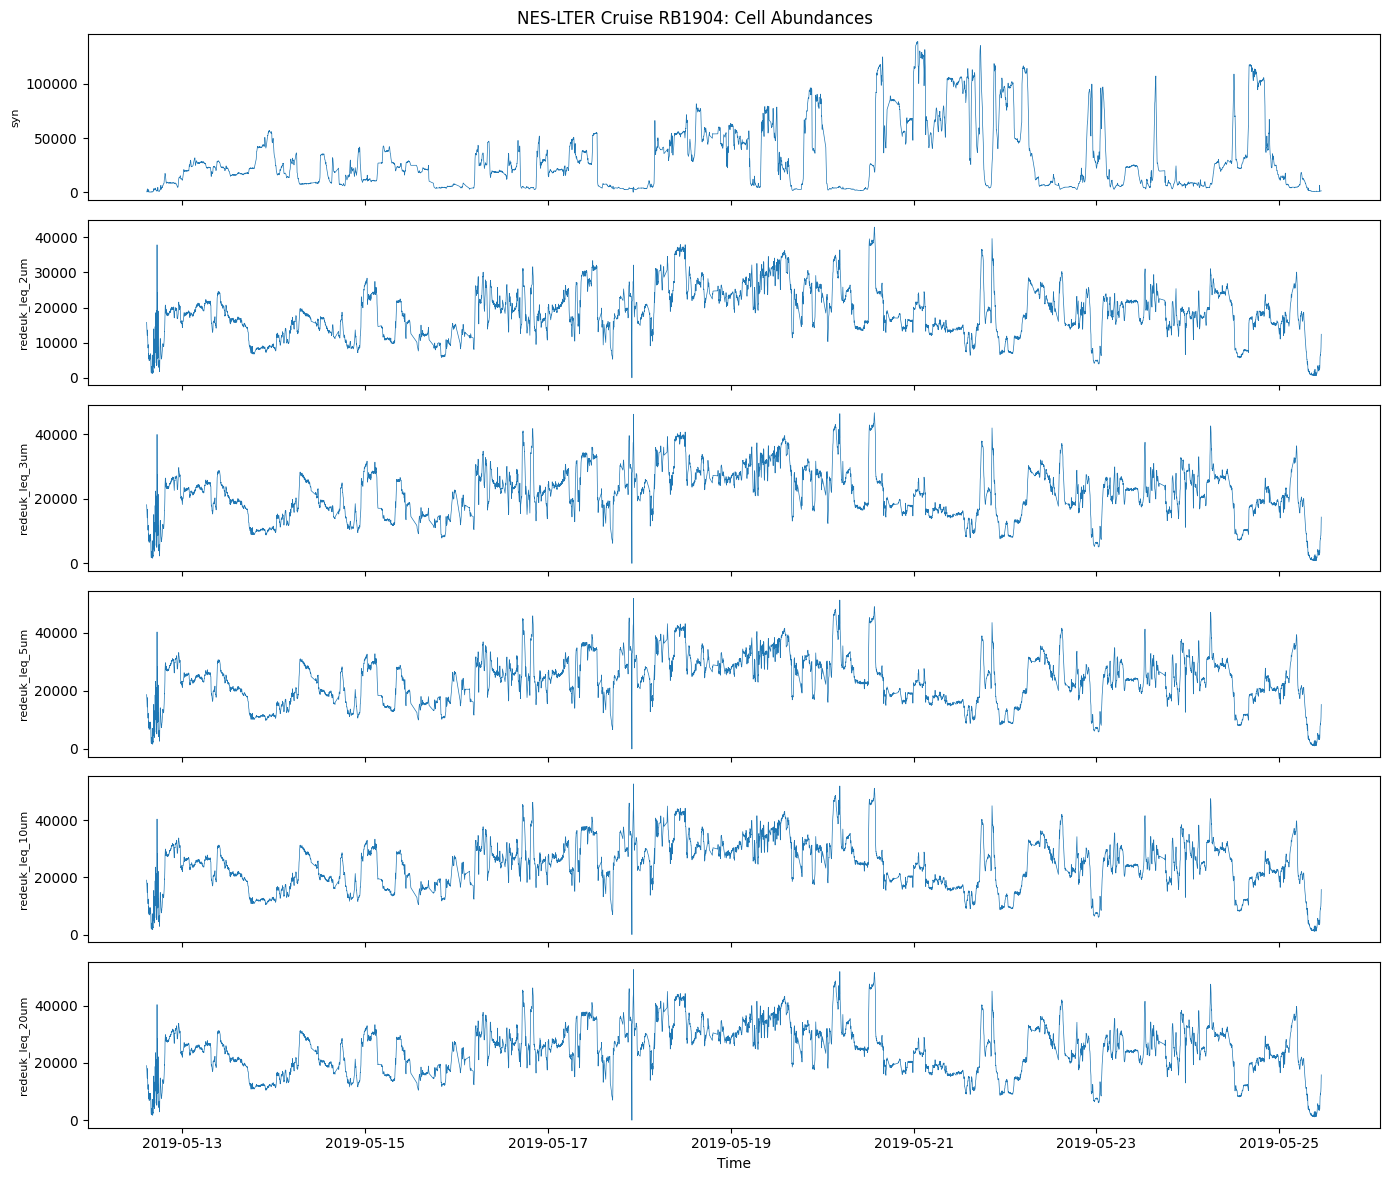

In [6]:
# Pick the largest cruise as an example
cruise_name = 'RB1904'
cruise = df[df['cruise'] == cruise_name].copy()

print(f"Cruise {cruise_name}")
print(f"  Samples: {len(cruise)}")
print(f"  Duration: {cruise['time'].min()} to {cruise['time'].max()}")
print(f"  Sampling interval (minutes):")
print((cruise['time'].diff().dt.total_seconds() / 60).describe())

cell_cols = ['syn_cells_per_ml', 'redeuk_leq_2um_cells_per_ml', 
             'redeuk_leq_3um_cells_per_ml', 'redeuk_leq_5um_cells_per_ml',
             'redeuk_leq_10um_cells_per_ml', 'redeuk_leq_20um_cells_per_ml']

fig, axs = plt.subplots(len(cell_cols), 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axs, cell_cols):
    ax.plot(cruise['time'], cruise[col], '-', lw=0.5)
    ax.set_ylabel(col.replace('_cells_per_ml', ''), fontsize=8)
axs[-1].set_xlabel('Time')
fig.suptitle(f'NES-LTER Cruise {cruise_name}: Cell Abundances', fontsize=12)
plt.tight_layout()
plt.savefig(f'nes_lter_{cruise_name}_timeseries.png', dpi=150)
plt.show()


### Save the full dataset

In [ ]:
df.to_csv('../data/hackathon_data/nes_lter_flow_cytometry.csv', index=False)
print(f"Saved: {df.shape}")
print("Saved to ../data/hackathon_data/nes_lter_flow_cytometry.csv")

Saved: (61420, 26)
Saved to nes_lter_flow_cytometry.csv
